# Bike Sharing Demand
<img src='images/bike.jpg' width=90% height=90%>

Bike sharing systems are a means of renting bicycles where the process of obtaining membership, rental, and bike return is automated via a network of kiosk locations throughout a city. Using these systems, people are able rent a bike from a one location and return it to a different place on an as-needed basis. Currently, there are over 500 bike-sharing programs around the world.

The data generated by these systems makes them attractive for researchers because the duration of travel, departure location, arrival location, and time elapsed is explicitly recorded. Bike sharing systems therefore function as a sensor network, which can be used for studying mobility in a city. In this competition, participants are asked to combine historical usage patterns with weather data in order to forecast bike rental demand in the Capital Bikeshare program in Washington, D.C.

# Load Dataset

In [125]:
# libraries
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from lightgbm import LGBMRegressor
from scipy.stats import normaltest
from sklearn import set_config
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import (GradientBoostingRegressor, RandomForestRegressor,
                              StackingRegressor)
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (MinMaxScaler, OneHotEncoder, OrdinalEncoder,
                                   PowerTransformer, RobustScaler)
from statsmodels.formula.api import ols
from xgboost import XGBRegressor

In [126]:
# filter warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# import data
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sampleSubmission.csv')

You are provided hourly rental data spanning two years. For this competition, the training set is comprised of the first 19 days of each month, while the test set is the 20th to the end of the month. You must predict the total count of bikes rented during each hour covered by the test set, using only information available prior to the rental period.

Data Fields:
* datetime - hourly date + timestamp  
* season
    * 1 = spring
    * 2 = summer
    * 3 = fall
    * 4 = winter 
* holiday - whether the day is considered a holiday
* workingday - whether the day is neither a weekend nor holiday
* weather
    * 1: Clear, Few clouds, Partly cloudy, Partly cloudy
    * 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
    * 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
    * 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog 
* temp - temperature in Celsius
* atemp - "feels like" temperature in Celsius
* humidity - relative humidity
* windspeed - wind speed
* casual - number of non-registered user rentals initiated
* registered - number of registered user rentals initiated
* count - number of total rentals

# Summarize Data

In [127]:
# head
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [128]:
# info
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


## Descriptive Statistics
### Categorical Features

In [129]:
# get categorical features
categorical_features = list(train.select_dtypes(exclude=[np.number]).columns)

# statistics
train[categorical_features].describe()

,datetime
count,10886
unique,10886
top,2011-01-01 00:00:00
freq,1


### Numeric Features

In [130]:
# get numeric features
numeric_features = list(train.select_dtypes(include=['int', 'float']).columns)

# summary statistics
display(train[numeric_features].describe())

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [131]:
numeric_features

['season',
 'holiday',
 'workingday',
 'weather',
 'temp',
 'atemp',
 'humidity',
 'windspeed',
 'casual',
 'registered',
 'count']

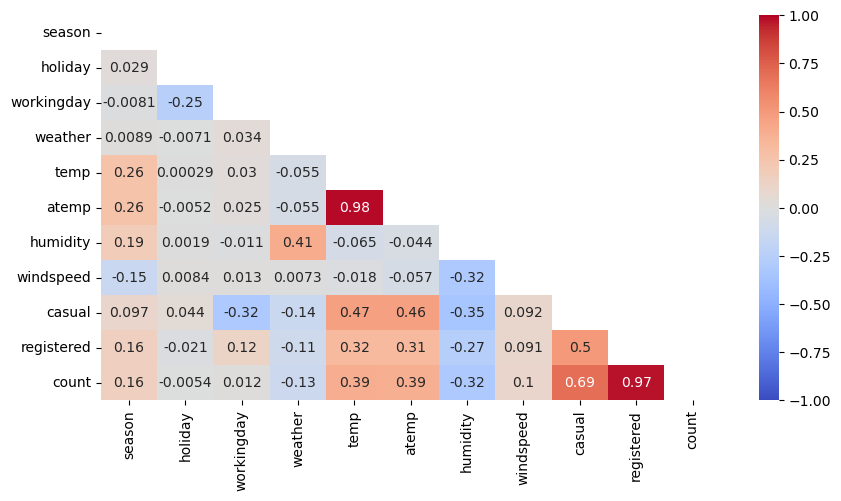

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
season,1.000000,0.029368,-0.008126,0.008879,0.258689,0.264744,0.190610,-0.147121,0.096758,0.164011,0.163439
holiday,0.029368,1.000000,-0.250491,-0.007074,0.000295,-0.005215,0.001929,0.008409,0.043799,-0.020956,-0.005393
workingday,-0.008126,-0.250491,1.000000,0.033772,0.029966,0.024660,-0.010880,0.013373,-0.319111,0.119460,0.011594
weather,0.008879,-0.007074,0.033772,1.000000,-0.055035,-0.055376,0.406244,0.007261,-0.135918,-0.109340,-0.128655
temp,0.258689,0.000295,0.029966,-0.055035,1.000000,0.984948,-0.064949,-0.017852,0.467097,0.318571,0.394454
atemp,0.264744,-0.005215,0.024660,-0.055376,0.984948,1.000000,-0.043536,-0.057473,0.462067,0.314635,0.389784
humidity,0.190610,0.001929,-0.010880,0.406244,-0.064949,-0.043536,1.000000,-0.318607,-0.348187,-0.265458,-0.317371
windspeed,-0.147121,0.008409,0.013373,0.007261,-0.017852,-0.057473,-0.318607,1.000000,0.092276,0.091052,0.101369
casual,0.096758,0.043799,-0.319111,-0.135918,0.467097,0.462067,-0.348187,0.092276,1.000000,0.497250,0.690414
registered,0.164011,-0.020956,0.119460,-0.109340,0.318571,0.314635,-0.265458,0.091052,0.497250,1.000000,0.970948


In [132]:
# correlation heatmap
matrix = np.triu(train[numeric_features].corr(method='pearson'))
plt.figure(figsize=(10,5))
sns.heatmap(train[numeric_features].corr(method='pearson'),annot=True, vmin=-1, vmax=1, center= 0, mask=matrix, cmap='coolwarm', fmt='.2g')
plt.show()
# correlation
train[numeric_features].corr()

# Data Cleaning
## Converting to categorical features

In [133]:
# rename season levels
train['season'] = train['season'].replace({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
test['season'] = test['season'].replace({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})

# rename workingday levels
train['workingday'] = train['workingday'].replace({0: 'No', 1: 'Yes'})
test['workingday'] = test['workingday'].replace({0: 'No', 1: 'Yes'})

# rename holiday levels
train['holiday'] = train['holiday'].replace({0: 'No', 1: 'Yes'})
test['holiday'] = test['holiday'].replace({0: 'No', 1: 'Yes'})

# rename weather
train['weather'] = train['weather'].replace({1: 'Clear', 2:'Cloudy', 3:'Light Precipitation', 4:'Heavy Precipitation'})
test['weather'] = test['weather'].replace({1: 'Clear', 2:'Cloudy', 3:'Light Precipitation', 4:'Heavy Precipitation'})

## Temp vs Atemp
Both features measure the weather. Temp has a higher correlation with the target, variable count.

In [134]:
# drop atemp
train = train.drop('atemp', axis='columns')
test = test.drop('atemp', axis='columns')

## Dropping Features
The features, 'casual' & 'registered', are not in the test set. It provides no predictive power.

In [135]:
# drop features
train = train.drop(['registered', 'casual'], axis='columns')

## Dates

In [136]:
# Date Fields
train['datetime'] = pd.to_datetime(train['datetime'])
train['dt_year'] = train['datetime'].dt.year.astype('category')
train['dt_month'] = train['datetime'].dt.month_name().astype('category')
train['dt_hour'] = train['datetime'].dt.hour.astype('category')
train['dt_day'] = train['datetime'].dt.day_name().astype('category')
train = train.drop('datetime', axis='columns')

test['datetime'] = pd.to_datetime(test['datetime'])
test['dt_year'] = test['datetime'].dt.year.astype('category')
test['dt_month'] = test['datetime'].dt.month_name().astype('category')
test['dt_hour'] = test['datetime'].dt.hour.astype('category')
test['dt_day'] = test['datetime'].dt.day_name().astype('category')
test = test.drop('datetime', axis='columns')
train.head()

,season,holiday,workingday,weather,temp,humidity,windspeed,count,dt_year,dt_month,dt_hour,dt_day
0,Spring,No,No,Clear,9.84,81,0.0,16,2011,January,0,Saturday
1,Spring,No,No,Clear,9.02,80,0.0,40,2011,January,1,Saturday
2,Spring,No,No,Clear,9.02,80,0.0,32,2011,January,2,Saturday
3,Spring,No,No,Clear,9.84,75,0.0,13,2011,January,3,Saturday
4,Spring,No,No,Clear,9.84,75,0.0,1,2011,January,4,Saturday


# Summarize Data, part 2
## Descriptive Statistics

In [137]:
# shape
print('The dataset has %d rows and %d columns. \n' % (train.shape[0], train.shape[1]))

The dataset has 10886 rows and 12 columns. 



In [138]:
train.head()

,season,holiday,workingday,weather,temp,humidity,windspeed,count,dt_year,dt_month,dt_hour,dt_day
0,Spring,No,No,Clear,9.84,81,0.0,16,2011,January,0,Saturday
1,Spring,No,No,Clear,9.02,80,0.0,40,2011,January,1,Saturday
2,Spring,No,No,Clear,9.02,80,0.0,32,2011,January,2,Saturday
3,Spring,No,No,Clear,9.84,75,0.0,13,2011,January,3,Saturday
4,Spring,No,No,Clear,9.84,75,0.0,1,2011,January,4,Saturday


In [139]:
# info
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   season      10886 non-null  object  
 1   holiday     10886 non-null  object  
 2   workingday  10886 non-null  object  
 3   weather     10886 non-null  object  
 4   temp        10886 non-null  float64 
 5   humidity    10886 non-null  int64   
 6   windspeed   10886 non-null  float64 
 7   count       10886 non-null  int64   
 8   dt_year     10886 non-null  category
 9   dt_month    10886 non-null  category
 10  dt_hour     10886 non-null  category
 11  dt_day      10886 non-null  category
dtypes: category(4), float64(2), int64(2), object(4)
memory usage: 723.3+ KB


## Numeric Features

In [140]:
# numeric features
numeric_features = list(train.select_dtypes(include=['int64', 'float']).columns)
train[numeric_features].describe()

,temp,humidity,windspeed,count
count,10886.00000,10886.000000,10886.000000,10886.000000
mean,20.23086,61.886460,12.799395,191.574132
std,7.79159,19.245033,8.164537,181.144454
min,0.82000,0.000000,0.000000,1.000000
25%,13.94000,47.000000,7.001500,42.000000
50%,20.50000,62.000000,12.998000,145.000000
75%,26.24000,77.000000,16.997900,284.000000
max,41.00000,100.000000,56.996900,977.000000


### D'Agostino's K2 test
In statistics, D'Agostino's K2 test, named for Ralph D'Agostino, is a goodness-of-fit measure of departure from normality, that is the test aims to establish whether or not the given sample comes from a normally distributed population. The test is based on transformations of the sample kurtosis and skewness, and has power only against the alternatives that the distribution is skewed and/or kurtic. 

https://en.wikipedia.org/wiki/D%27Agostino%27s_K-squared_test

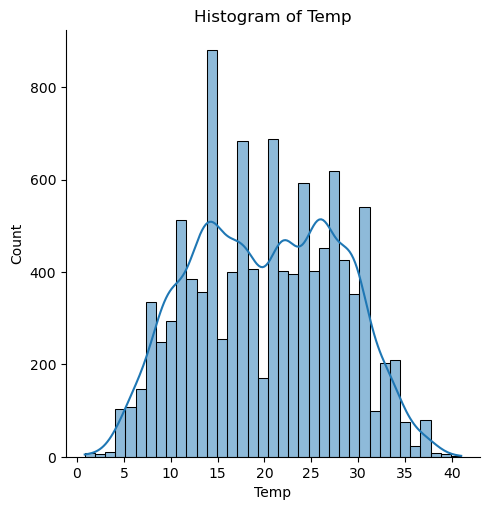

'temp' is not normally distributed with a p-value of 0.0000.


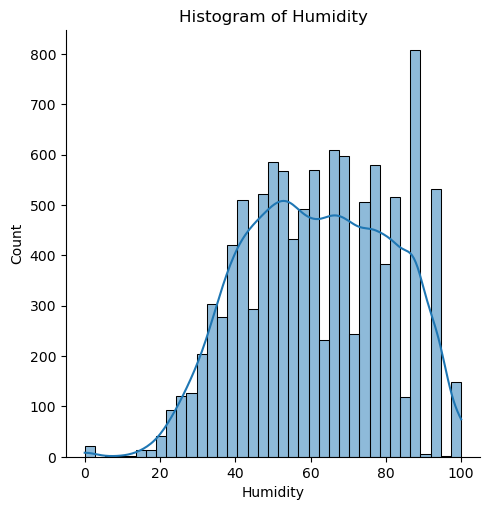

'humidity' is not normally distributed with a p-value of 0.0000.


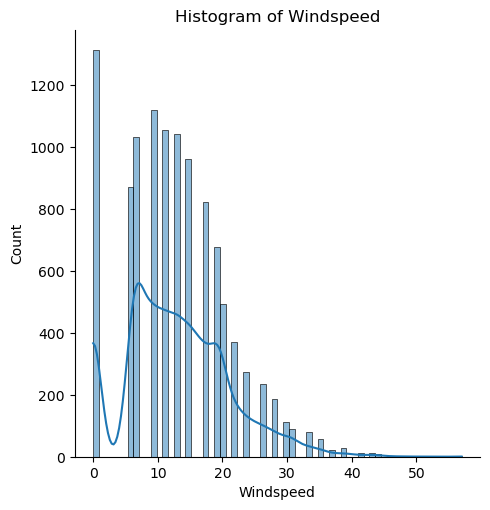

'windspeed' is not normally distributed with a p-value of 0.0000.


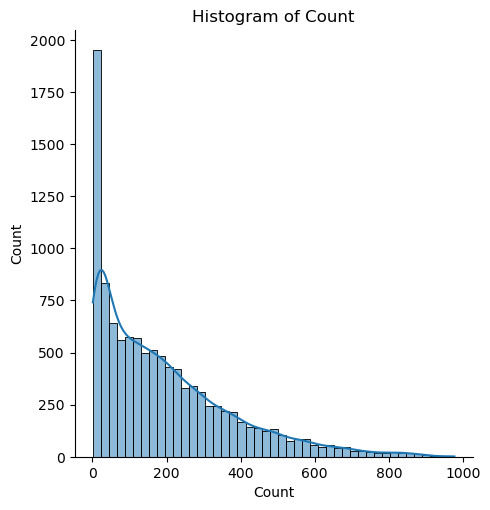

'count' is not normally distributed with a p-value of 0.0000.


In [141]:
# test for normality and graphs
for feature in numeric_features:
    sns.displot(train[feature], palette='colorblind', kde=True)
    title = 'Histogram of ' + feature.capitalize()
    plt.title(title)
    plt.xlabel(feature.capitalize())
    plt.show()
    if normaltest(train[feature])[1] >= 0.05:
        print('\'{}\' is normally distributed with a p-value of {:.4f}.'.format(feature, normaltest(train[feature])[1]))
    else:
        print('\'{}\' is not normally distributed with a p-value of {:.4f}.'.format(feature, normaltest(train[feature])[1]))

### Correlation
Windspeed has a very low correlation. Can consider dropping.

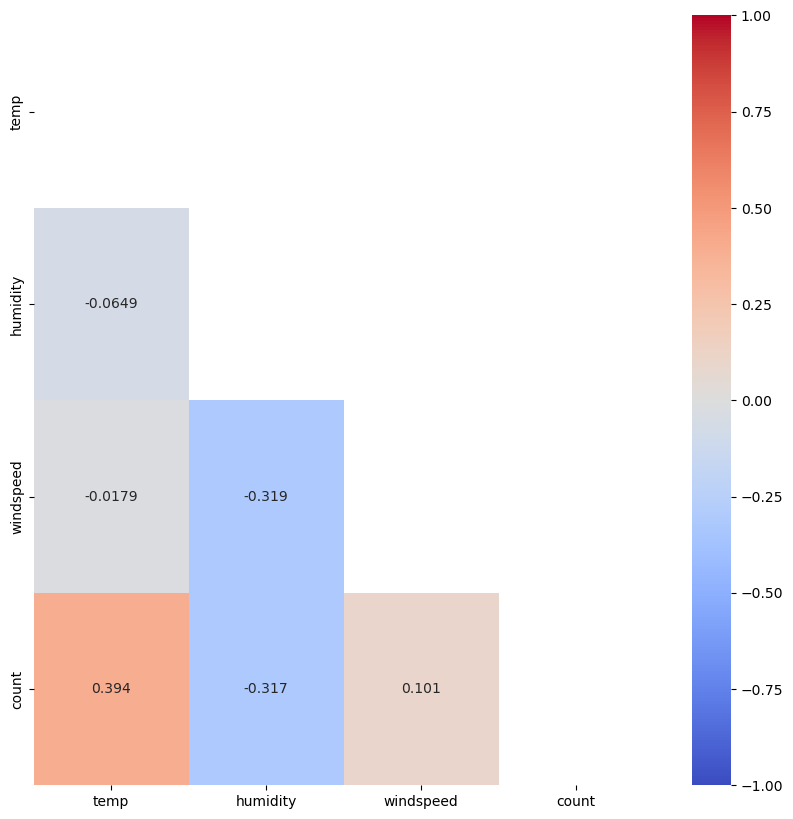

,temp,humidity,windspeed,count
temp,1.000000,-0.064949,-0.017852,0.394454
humidity,-0.064949,1.000000,-0.318607,-0.317371
windspeed,-0.017852,-0.318607,1.000000,0.101369
count,0.394454,-0.317371,0.101369,1.000000


In [142]:
# correlation heatmap
matrix = np.triu(train[numeric_features].corr(method='pearson'))
plt.figure(figsize=(10,10))
sns.heatmap(train[numeric_features].corr(method='pearson'),annot=True, vmin=-1, vmax=1, center= 0, mask=matrix, cmap='coolwarm', fmt='.3g')
plt.show()
# correlation
train[numeric_features].corr()

## Categorical Features

In [143]:
categorical_features = list(train.select_dtypes(include=['object', 'category']).columns)
train[categorical_features].describe()

,season,holiday,workingday,weather,dt_year,dt_month,dt_hour,dt_day
count,10886,10886,10886,10886,10886,10886,10886,10886
unique,4,2,2,4,2,12,24,7
top,Winter,No,Yes,Clear,2012,August,12,Saturday
freq,2734,10575,7412,7192,5464,912,456,1584


### Count Plots

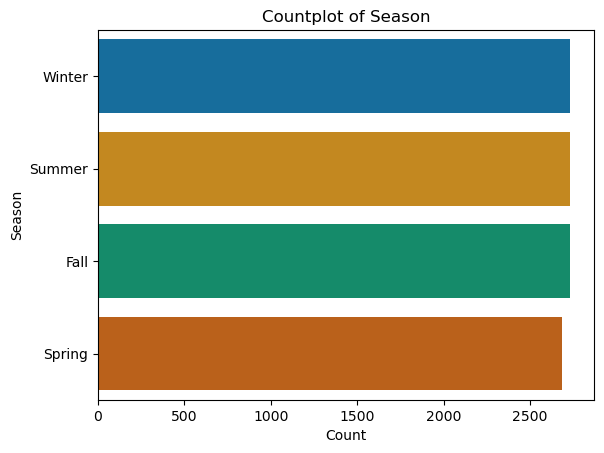

        count
season       
Winter   2734
Summer   2733
Fall     2733
Spring   2686


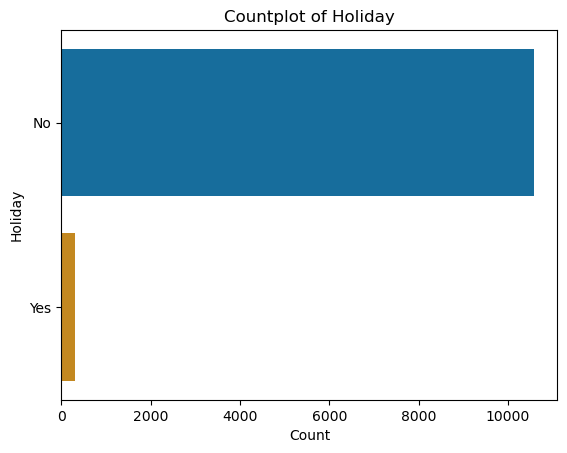

         count
holiday       
No       10575
Yes        311


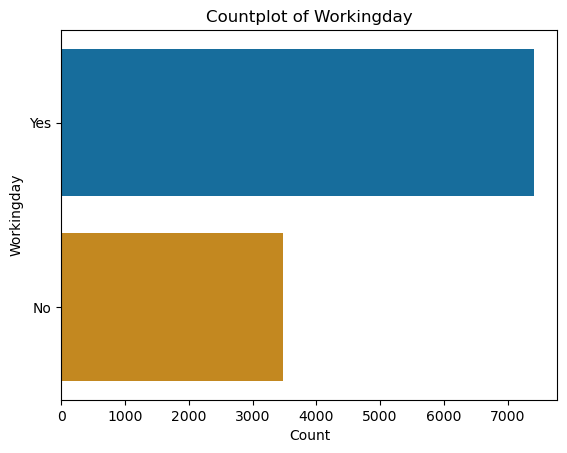

            count
workingday       
Yes          7412
No           3474


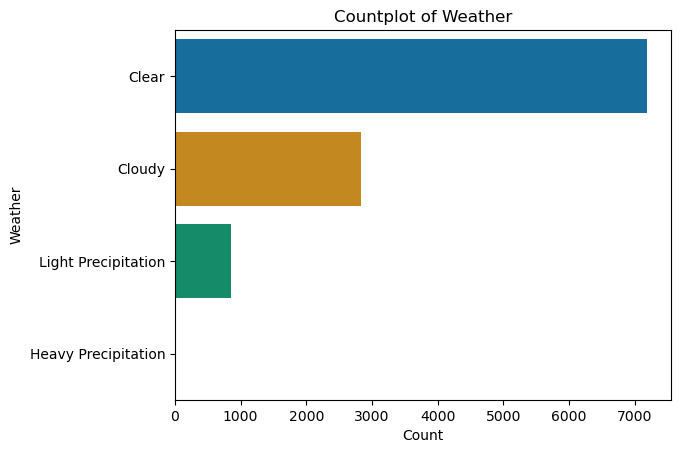

                     count
weather                   
Clear                 7192
Cloudy                2834
Light Precipitation    859
Heavy Precipitation      1


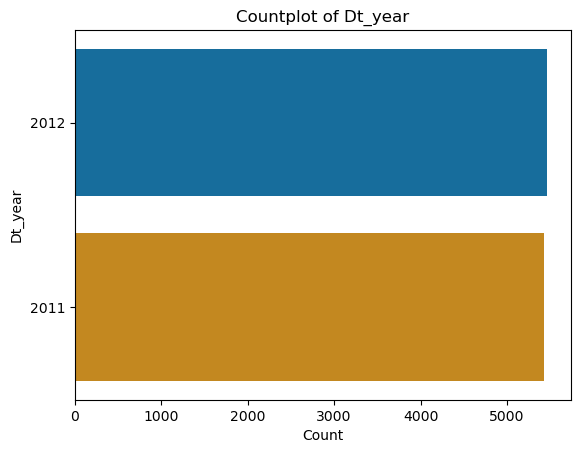

         count
dt_year       
2012      5464
2011      5422


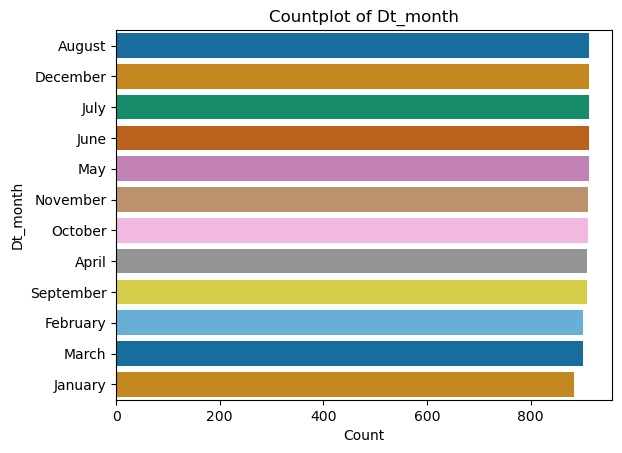

           count
dt_month        
August       912
December     912
July         912
June         912
May          912
November     911
October      911
April        909
September    909
February     901
March        901
January      884


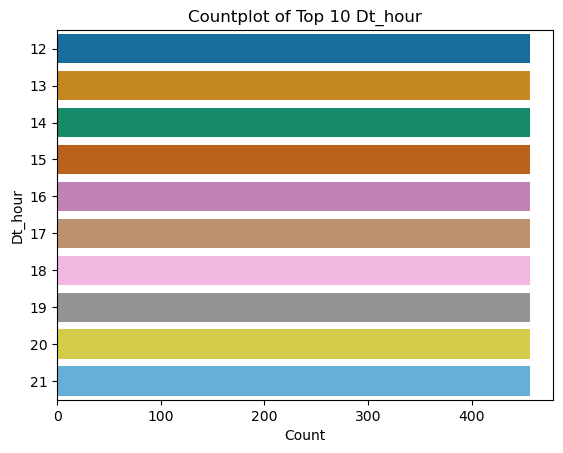

         count
dt_hour       
12         456
13         456
14         456
15         456
16         456
17         456
18         456
19         456
20         456
21         456


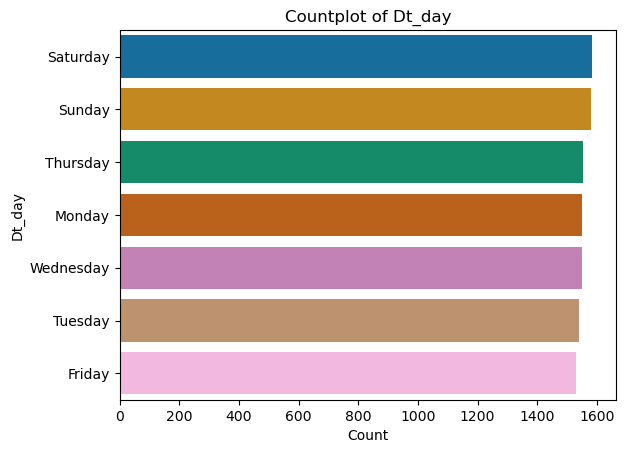

           count
dt_day          
Saturday    1584
Sunday      1579
Thursday    1553
Monday      1551
Wednesday   1551
Tuesday     1539
Friday      1529


In [144]:
# count plots
for feature in categorical_features:
    if train[feature].nunique() < 15:
        sns.countplot(y=feature, data=train, palette='colorblind', order = train[feature].value_counts().index)
        plt.title('Countplot of {}'.format(feature.capitalize()))
        plt.xlabel('Count')
        plt.ylabel(feature.capitalize())
        plt.show()
        print(pd.DataFrame(train[feature].value_counts()))
    else:
        sns.countplot(y=feature, data=train, palette='colorblind', order = train[feature].value_counts().iloc[:10].index)
        plt.title('Countplot of Top 10 {}'.format(feature.capitalize()))
        plt.xlabel('Count')
        plt.ylabel(feature.capitalize())
        plt.show()
        print(pd.DataFrame(train[feature].value_counts().iloc[:10]))

### ANOVA

In [145]:
# list of independent features
independent_features = []
# Function for Anova
def aov(cat):
    # features
    num = 'count'
    cat = cat
    # create formula
    formula = num + ' ~ ' + cat
    # create ols
    mod = ols(formula, data=train).fit()
    # aov table                
    aov_table = sm.stats.anova_lm(mod, typ=2)
    # plot boxplot
    if train[cat].nunique() > 15:
        plt.figure(figsize=(7,10))
        sns.boxplot(y=cat, x=num, palette='colorblind', data=train, width=0.2, fliersize=1)
        plt.title('Boxplot of {} by {}'.format(num.capitalize(), cat.capitalize()))
        plt.xlabel(num.capitalize())
        plt.ylabel(cat.capitalize())
        plt.show()
    else:
        plt.figure(figsize=(5,5))
        sns.boxplot(y=cat, x=num, palette='colorblind', data=train, width=0.2, fliersize=1)
        plt.title('Boxplot of {} by {}'.format(num.capitalize(), cat.capitalize()))
        plt.xlabel(num.capitalize())
        plt.ylabel(cat.capitalize())
        plt.show()
    # display mean of group
    display('Means by Group:')
    display(train.groupby(cat, as_index=False)[num].mean())
    # display aov results
    display('AOV Results:')
    display(aov_table)
    # display pairwise comparison
    display('Pairwise Comparisons:')
    pair_t = mod.t_test_pairwise(cat)
    display(pair_t.result_frame)
    # get p-value of F and compare
    PR_F = sm.stats.anova_lm(mod, typ=2)['PR(>F)'].values[0]
    if PR_F < 0.10:
        print('The features of \'{}\' and \'{}\' are {} with a p-value of {:.4f}.'.format(num, cat, 'dependent', PR_F))
    else:
        print('The features of \'{}\' and \'{}\' are {} with a p-value of {:.4f}.'.format(num, cat, 'independent', PR_F))
        independent_features.append(cat)

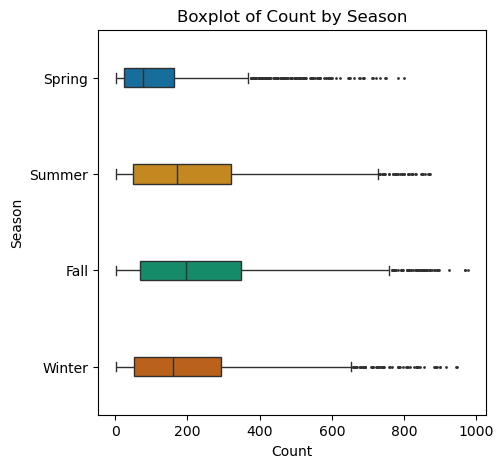

'Means by Group:'

,season,count
0,Fall,234.417124
1,Spring,116.343261
2,Summer,215.251372
3,Winter,198.988296


'AOV Results:'

,sum_sq,df,F,PR(>F)
season,2.190083e+07,3.0,236.946711,6.164843e-149
Residual,3.352721e+08,10882.0,NaN,NaN


'Pairwise Comparisons:'

,coef,std err,t,P>|t|,Conf. Int. Low,Conf. Int. Upp.,pvalue-hs,reject-hs
Spring-Fall,-118.073863,4.769041,-24.758406,1.063174e-131,-127.422052,-108.725674,6.379046e-131,True
Summer-Fall,-19.165752,4.748315,-4.036327,5.466633e-05,-28.473313,-9.858190,1.093297e-04,True
Winter-Fall,-35.428829,4.747881,-7.462030,9.169927e-14,-44.735539,-26.122118,2.750978e-13,True
Summer-Spring,98.908111,4.769041,20.739621,9.756471e-94,89.559922,108.256300,4.878235e-93,True
Winter-Spring,82.645034,4.768609,17.331057,2.127949e-66,73.297693,91.992376,8.511796e-66,True
Winter-Summer,-16.263077,4.747881,-3.425334,6.163118e-04,-25.569787,-6.956366,6.163118e-04,True


The features of 'count' and 'season' are dependent with a p-value of 0.0000.


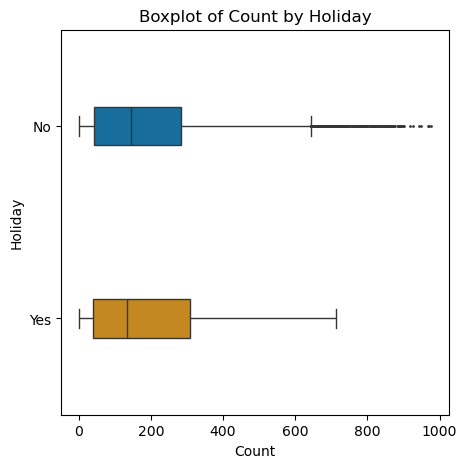

'Means by Group:'

,holiday,count
0,No,191.741655
1,Yes,185.877814


'AOV Results:'

,sum_sq,df,F,PR(>F)
holiday,1.038812e+04,1.0,0.316563,0.573692
Residual,3.571625e+08,10884.0,NaN,NaN


'Pairwise Comparisons:'

,coef,std err,t,P>|t|,Conf. Int. Low,Conf. Int. Upp.,pvalue-hs,reject-hs
Yes-No,-5.863841,10.422033,-0.562639,0.573692,-26.292923,14.56524,0.573692,False


The features of 'count' and 'holiday' are independent with a p-value of 0.5737.


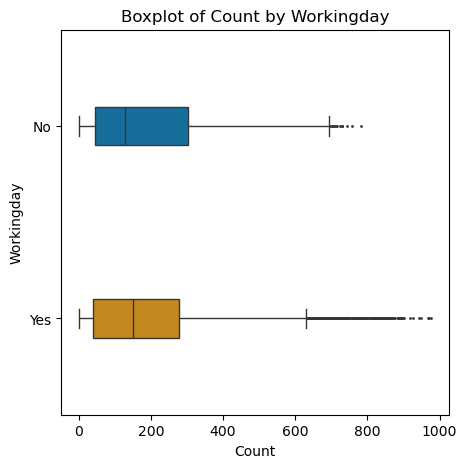

'Means by Group:'

,workingday,count
0,No,188.506621
1,Yes,193.011873


'AOV Results:'

,sum_sq,df,F,PR(>F)
workingday,4.801037e+04,1.0,1.463199,0.226448
Residual,3.571249e+08,10884.0,NaN,NaN


'Pairwise Comparisons:'

,coef,std err,t,P>|t|,Conf. Int. Low,Conf. Int. Upp.,pvalue-hs,reject-hs
Yes-No,4.505252,3.724495,1.209628,0.226448,-2.795435,11.805939,0.226448,False


The features of 'count' and 'workingday' are independent with a p-value of 0.2264.


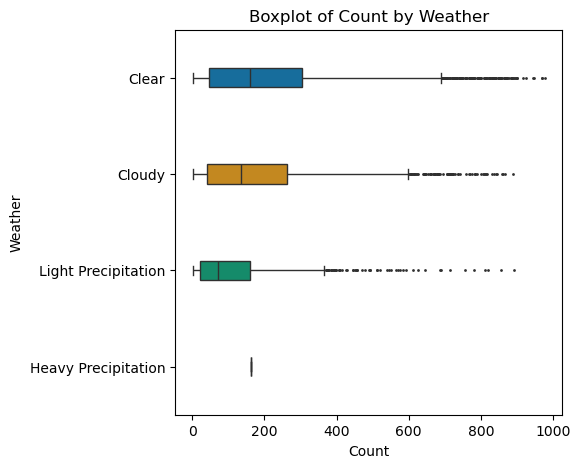

'Means by Group:'

,weather,count
0,Clear,205.236791
1,Cloudy,178.955540
2,Heavy Precipitation,164.000000
3,Light Precipitation,118.846333


'AOV Results:'

,sum_sq,df,F,PR(>F)
weather,6.338070e+06,3.0,65.530241,5.482069e-42
Residual,3.508348e+08,10882.0,NaN,NaN


'Pairwise Comparisons:'

,coef,std err,t,P>|t|,Conf. Int. Low,Conf. Int. Upp.,pvalue-hs,reject-hs
Cloudy-Clear,-26.281251,3.982319,-6.599483,4.317735e-11,-34.087322,-18.475180,1.727094e-10,True
Heavy Precipitation-Clear,-41.236791,179.567274,-0.229645,8.183717e-01,-393.221331,310.747749,9.921862e-01,False
Light Precipitation-Clear,-86.390458,6.481873,-13.328009,3.285377e-40,-99.096108,-73.684808,1.971226e-39,True
Heavy Precipitation-Cloudy,-14.955540,179.586467,-0.083278,9.336323e-01,-366.977702,337.066622,9.921862e-01,False
Light Precipitation-Cloudy,-60.109207,6.993429,-8.595098,9.457082e-18,-73.817600,-46.400814,4.728541e-17,True
Light Precipitation-Heavy Precipitation,-45.153667,179.659275,-0.251329,8.015642e-01,-397.318545,307.011211,9.921862e-01,False


The features of 'count' and 'weather' are dependent with a p-value of 0.0000.


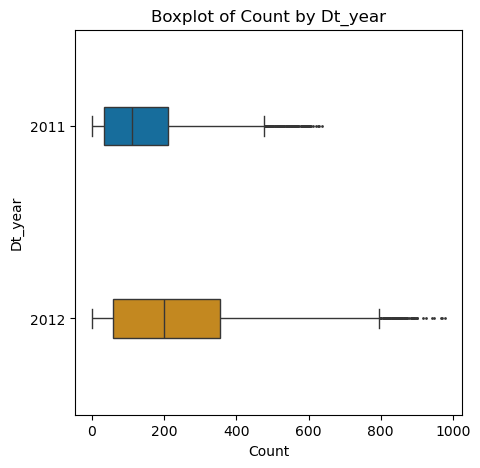

'Means by Group:'

,dt_year,count
0,2011,144.223349
1,2012,238.560944


'AOV Results:'

,sum_sq,df,F,PR(>F)
dt_year,2.421985e+07,1.0,791.729805,3.242014e-168
Residual,3.329531e+08,10884.0,NaN,NaN


'Pairwise Comparisons:'

,coef,std err,t,P>|t|,Conf. Int. Low,Conf. Int. Upp.,pvalue-hs,reject-hs
2012-2011,94.337595,3.352712,28.137694,3.242014e-168,87.765669,100.909521,3.242014e-168,True


The features of 'count' and 'dt_year' are dependent with a p-value of 0.0000.


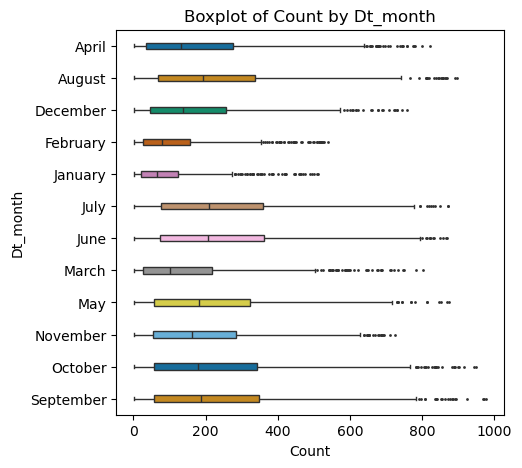

'Means by Group:'

,dt_month,count
0,April,184.160616
1,August,234.118421
2,December,175.614035
3,February,110.003330
4,January,90.366516
5,July,235.325658
6,June,242.031798
7,March,148.169811
8,May,219.459430
9,November,193.677278


'AOV Results:'

,sum_sq,df,F,PR(>F)
dt_month,2.627121e+07,11.0,78.483391,3.967012e-171
Residual,3.309017e+08,10874.0,NaN,NaN


'Pairwise Comparisons:'

,coef,std err,t,P>|t|,Conf. Int. Low,Conf. Int. Upp.,pvalue-hs,reject-hs
August-April,49.957805,8.175804,6.110446,1.027556e-09,33.931741,65.983869,3.493692e-08,True
December-April,-8.546581,8.175804,-1.045351,2.958842e-01,-24.572645,7.479483,9.789096e-01,False
February-April,-74.157286,8.200678,-9.042823,1.785758e-19,-90.232110,-58.082463,8.035912e-18,True
January-April,-93.794100,8.240184,-11.382525,7.538009e-30,-109.946362,-77.641839,3.919765e-28,True
July-April,51.165042,8.175804,6.258106,4.043530e-10,35.138977,67.191106,1.415236e-08,True
...,...,...,...,...,...,...,...,...
October-May,8.239802,8.171308,1.008382,3.132934e-01,-7.777450,24.257053,9.789096e-01,False
September-May,14.345851,8.175804,1.754672,7.934365e-02,-1.680214,30.371915,6.856845e-01,False
October-November,34.021954,8.173549,4.162446,3.172824e-05,18.000310,50.043598,6.977888e-04,True
September-November,40.128003,8.178043,4.906798,9.391786e-07,24.097548,56.158457,2.441836e-05,True


The features of 'count' and 'dt_month' are dependent with a p-value of 0.0000.


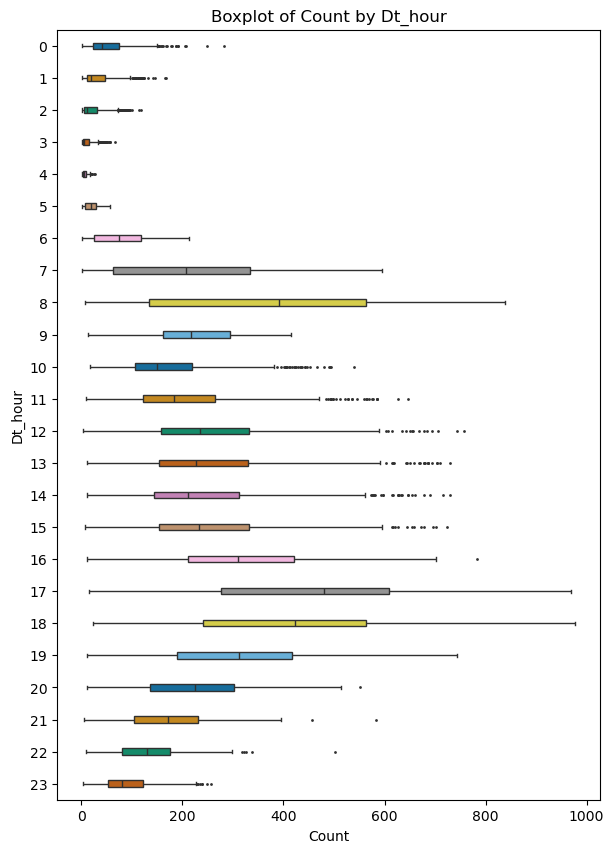

'Means by Group:'

,dt_hour,count
0,0,55.138462
1,1,33.859031
2,2,22.899554
3,3,11.757506
4,4,6.407240
5,5,19.767699
6,6,76.259341
7,7,213.116484
8,8,362.769231
9,9,221.780220


'AOV Results:'

,sum_sq,df,F,PR(>F)
dt_hour,1.845339e+08,23.0,504.799696,0.0
Residual,1.726390e+08,10862.0,NaN,NaN


'Pairwise Comparisons:'

,coef,std err,t,P>|t|,Conf. Int. Low,Conf. Int. Upp.,pvalue-hs,reject-hs
1-0,-21.279431,8.363016,-2.544469,1.095814e-02,-37.672467,-4.886394,2.491010e-01,False
2-0,-32.238908,8.391001,-3.842081,1.226897e-04,-48.686800,-15.791016,4.163016e-03,True
3-0,-43.380956,8.463918,-5.125399,3.020133e-07,-59.971778,-26.790133,1.510055e-05,True
4-0,-48.731222,8.419649,-5.787797,7.328880e-09,-65.235270,-32.227174,4.397327e-07,True
5-0,-35.370762,8.372272,-4.224751,2.411578e-05,-51.781943,-18.959582,9.400848e-04,True
...,...,...,...,...,...,...,...,...
22-20,-94.940789,8.349244,-11.371183,8.575141e-30,-111.306831,-78.574747,8.660892e-28,True
23-20,-139.008772,8.349244,-16.649264,1.765690e-61,-155.374814,-122.642730,2.330711e-59,True
22-21,-39.793860,8.349244,-4.766163,1.902030e-06,-56.159902,-23.427818,8.748964e-05,True
23-21,-83.861842,8.349244,-10.044243,1.234910e-23,-100.227884,-67.495800,1.148466e-21,True


The features of 'count' and 'dt_hour' are dependent with a p-value of 0.0000.


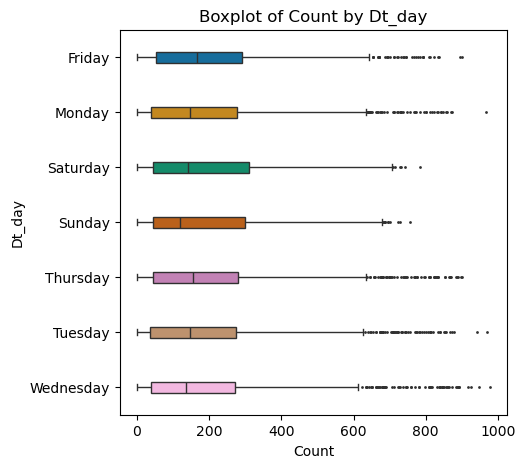

'Means by Group:'

,dt_day,count
0,Friday,197.844343
1,Monday,190.390716
2,Saturday,196.665404
3,Sunday,180.839772
4,Thursday,197.296201
5,Tuesday,189.723847
6,Wednesday,188.411348


'AOV Results:'

,sum_sq,df,F,PR(>F)
dt_day,3.569194e+05,6.0,1.813692,0.092198
Residual,3.568160e+08,10879.0,NaN,NaN


'Pairwise Comparisons:'

,coef,std err,t,P>|t|,Conf. Int. Low,Conf. Int. Upp.,pvalue-hs,reject-hs
Monday-Friday,-7.453627,6.526696,-1.142021,0.253470,-20.247140,5.339885,0.964162,False
Saturday-Friday,-1.178939,6.492858,-0.181575,0.855920,-13.906122,11.548245,0.999896,False
Sunday-Friday,-17.004571,6.497905,-2.616931,0.008885,-29.741648,-4.267494,0.170898,False
Thursday-Friday,-0.548142,6.524609,-0.084011,0.933049,-13.337564,12.241280,0.999896,False
Tuesday-Friday,-8.120496,6.539316,-1.241796,0.214339,-20.938745,4.697753,0.957557,False
Wednesday-Friday,-9.432995,6.526696,-1.445294,0.148404,-22.226508,3.360517,0.934842,False
Saturday-Monday,6.274688,6.469384,0.969905,0.332115,-6.406483,18.955860,0.964162,False
Sunday-Monday,-9.550944,6.474450,-1.475175,0.140195,-22.242044,3.140157,0.934052,False
Thursday-Monday,6.905485,6.501250,1.062178,0.288178,-5.838149,19.649120,0.964162,False
Tuesday-Monday,-0.666869,6.516009,-0.102343,0.918486,-13.439434,12.105696,0.999896,False


The features of 'count' and 'dt_day' are dependent with a p-value of 0.0922.


In [146]:
for feature in categorical_features:
    aov(feature)

In [147]:
# features with little/no predictive power
print('The following features have little/no predictive power: {}.'.format(', '.join(independent_features)))
train = train.drop(['windspeed', 'dt_month'], axis='columns')
test = test.drop(['windspeed', 'dt_month'], axis='columns')
train.head()

The following features have little/no predictive power: holiday, workingday.


,season,holiday,workingday,weather,temp,humidity,count,dt_year,dt_hour,dt_day
0,Spring,No,No,Clear,9.84,81,16,2011,0,Saturday
1,Spring,No,No,Clear,9.02,80,40,2011,1,Saturday
2,Spring,No,No,Clear,9.02,80,32,2011,2,Saturday
3,Spring,No,No,Clear,9.84,75,13,2011,3,Saturday
4,Spring,No,No,Clear,9.84,75,1,2011,4,Saturday


# Mutual Information Statistic

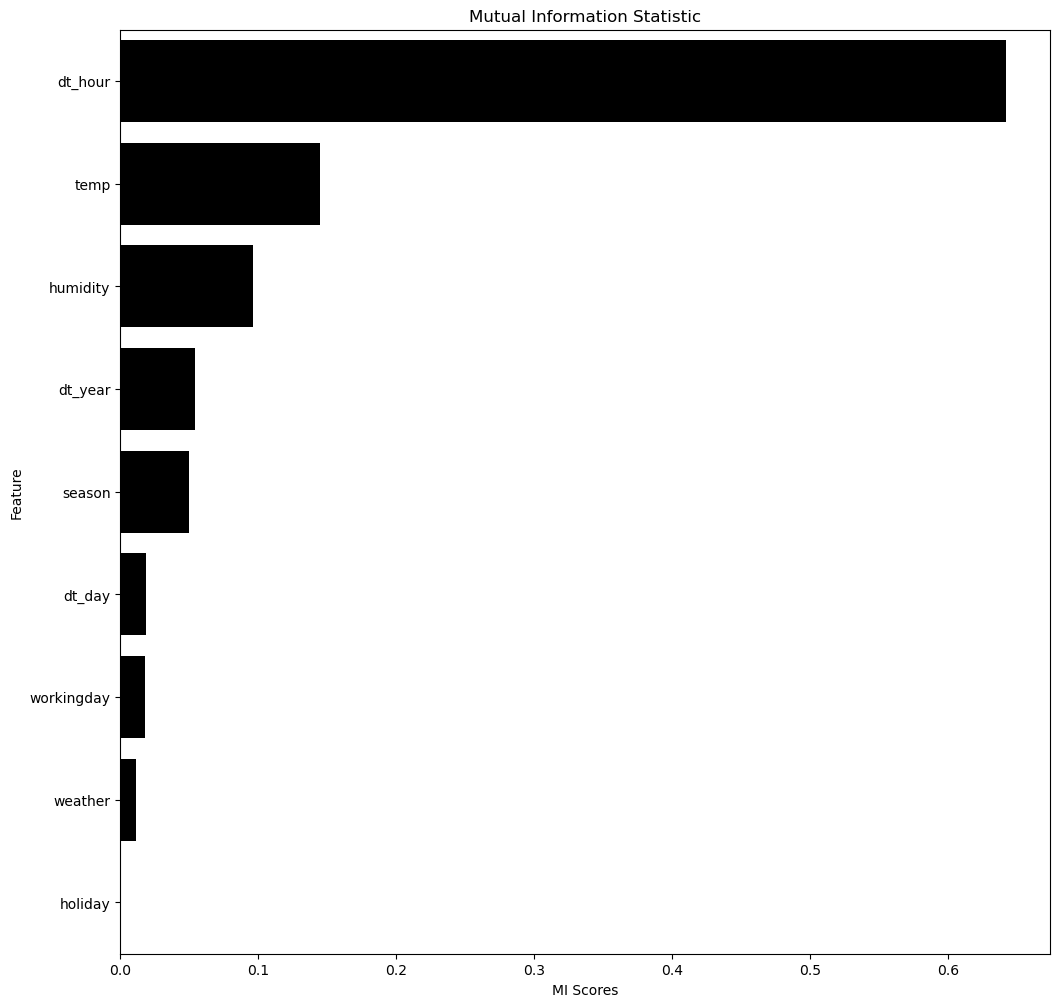

,Feature,MI Scores
5,dt_hour,0.64180
7,temp,0.14479
8,humidity,0.09635
4,dt_year,0.05388
0,season,0.04997
6,dt_day,0.01867
2,workingday,0.01779
3,weather,0.01159
1,holiday,0.00067


In [148]:
# Split into X, y
X = train.drop(['count'], axis='columns')
y = train['count']

# numeric pipeline
numeric_pipeline_steps = []
numeric_pipeline_steps.append(('ii_imputer', IterativeImputer()))
numeric_pipeline_steps.append(('min-max', MinMaxScaler(feature_range=(1, 2))))
numeric_pipeline_steps.append(('box-cox', PowerTransformer(method='box-cox')))
numeric_pipeline = Pipeline(steps=numeric_pipeline_steps)

# categorical pipeline
categorical_pipeline_steps = []
categorical_pipeline_steps.append(('si_impute', SimpleImputer(strategy='constant', fill_value='missing')))
categorical_pipeline_steps.append(('oe', OrdinalEncoder(dtype=np.int64)))
categorical_pipeline = Pipeline(steps=categorical_pipeline_steps)

# create transformer
cat_columns = X.select_dtypes(exclude=np.number).columns.tolist()
num_columns = X.select_dtypes(include=np.number).columns.tolist()

# transformer steps
transformer_steps = []
transformer_steps.append(('cat', categorical_pipeline, cat_columns))
transformer_steps.append(('num', numeric_pipeline, num_columns))
preprocessing_transformer=ColumnTransformer(transformers=transformer_steps)

# preprocessing transformer
preprocessing_transformer

# preprocess X data
pp_X = preprocessing_transformer.fit_transform(X)

# target pipeline (min-max, box-cox)
target_pipeline_steps = []
target_pipeline_steps.append(('min-max', MinMaxScaler(feature_range=(1,2))))
target_pipeline_steps.append(('boxcox', PowerTransformer(method=('box-cox'))))
target_pipeline = Pipeline(steps=target_pipeline_steps)

# preprocess y data
y = target_pipeline.fit_transform(np.reshape(y, (-1, 1))).ravel()

# Get feature names out
raw_features = preprocessing_transformer.get_feature_names_out()

# get discrete feature indices
discrete_features_for_mi = [col.startswith('cat__') for col in raw_features]

# create dataframe for results
pp_X_columns = pd.Series(raw_features).str.replace(r'^(num__|cat__)', '', regex=True)
pp_X_df = pd.DataFrame(pp_X, columns=pp_X_columns)

# run mutual_info_regression
mi_scores = mutual_info_regression(pp_X_df, y, discrete_features=discrete_features_for_mi, random_state=2022)

# make df of mi
mi_scores_df = pd.DataFrame({'Feature': pp_X_df.columns, 'MI Scores': mi_scores}).sort_values('MI Scores', ascending=False)

# bar plot
plt.figure(figsize=(12, 12))
sns.barplot(y='Feature', x='MI Scores', data=mi_scores_df, color='black')
plt.title('Mutual Information Statistic')
plt.show()

# dataframe of mi scores
display(mi_scores_df.round(5))

# Model Setup

In [149]:
# Split into X, y
X = train.drop(['count'], axis='columns')
y = train['count']

# Train & Validation Sets
X_train, X_validate, y_train, y_validate = train_test_split(X, y, test_size=0.30)

# Separate Columns by type
numeric_features = X.select_dtypes(include=[np.number]).columns
categorical_features = X.select_dtypes(exclude=[np.number]).columns

In [150]:
# seperate high and low cardinality features
n_unique_categories = X_train[categorical_features].nunique()
high_cardinality_features = n_unique_categories[n_unique_categories > 50].index
low_cardinality_features = n_unique_categories[n_unique_categories <= 50].index

In [151]:
def df_describe_categorical(df: pd.DataFrame) -> pd.DataFrame:
    # get categorical columns
    cat_df = df.select_dtypes(exclude=np.number)

    # return empty dataframe if empty
    if cat_df.empty:
        return pd.DataFrame()

    # get number of observations
    counts = cat_df.count()

    # get missing
    n_missing = cat_df.isna().sum()

    # get number of unique values
    uniques = cat_df.nunique()

    # get mode
    modes_df = cat_df.mode().iloc[0]

    # get top categories
    top_categories = modes_df.astype(str)

    # get top category frequency
    top_freqs = (cat_df == modes_df).sum()

    # get percentage of top category
    top_pcts = ((top_freqs / counts).round(2) * 100).astype(int).astype(str) + "%"

    # build dataframe
    summary_df = pd.DataFrame(
        {
            "Column": cat_df.columns,
            "Data Type": cat_df.dtypes,
            "Count": counts,
            "Missing Values": n_missing,
            "Unique Values": uniques,
            "Top Category": top_categories,
            "Top Category Frequency": top_freqs,
            "% Top Category": top_pcts,
        }
    ).reset_index(drop=True)

    return summary_df

In [152]:
df_describe_categorical(X_train[high_cardinality_features])

""


In [153]:
df_describe_categorical(X_train[low_cardinality_features])

,Column,Data Type,Count,Missing Values,Unique Values,Top Category,Top Category Frequency,% Top Category
0,season,object,7620,0,4,Summer,1937,25%
1,holiday,object,7620,0,2,No,7400,97%
2,workingday,object,7620,0,2,Yes,5168,68%
3,weather,object,7620,0,4,Clear,5020,66%
4,dt_year,category,7620,0,2,2011,3836,50%
5,dt_hour,category,7620,0,24,23,337,4%
6,dt_day,category,7620,0,7,Saturday,1119,15%


In [154]:
# Categorical Feature Pipeline (OneHot)
low_categorical_pipeline_steps = []
low_categorical_pipeline_steps.append(('onehot', OneHotEncoder(handle_unknown='ignore')))
low_categorical_pipeline = Pipeline(steps=low_categorical_pipeline_steps)

# Numeric Feature Pipeline (min-max, box-cox)
numeric_pipeline_steps = []
numeric_pipeline_steps.append(('robust', RobustScaler()))
numeric_pipeline_steps.append(('min-max', MinMaxScaler(feature_range=(1,2))))
numeric_pipeline_steps.append(('box-cox', PowerTransformer(method='box-cox')))
numeric_pipeline = Pipeline(steps=numeric_pipeline_steps)

# Preprocessing Transformer
preprocessing_transformer_steps = []
preprocessing_transformer_steps.append(('low_cat', low_categorical_pipeline, low_cardinality_features))
preprocessing_transformer_steps.append(('num', numeric_pipeline, numeric_features))
preprocessing_transformer=ColumnTransformer(transformers=preprocessing_transformer_steps)

# target pipeline (min-max, box-cox)
target_pipeline_steps = []
target_pipeline_steps.append(('boxcox', PowerTransformer(method=('box-cox'))))
target_pipeline = Pipeline(steps=target_pipeline_steps)

# Display Transformer
set_config(display='diagram')
preprocessing_transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('low_cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_na

# Spot-Check Algorithms

In [155]:
# Spot-Check Algorithms #####
# Store Results
results = pd.DataFrame()
scoring = 'neg_mean_squared_log_error'

models = []
models.append(('lgbm', LGBMRegressor(n_estimators=100, verbosity=-1, silent=True)))
models.append(('xgb', XGBRegressor(n_estimators=100)))

for name, model in models:
    # Pipeline
    model_pipeline_steps = []
    model_pipeline_steps.append(('transformer', preprocessing_transformer))
    model_pipeline_steps.append(('model', model))
    model_pipeline = Pipeline(steps=model_pipeline_steps)
    transformed_model = TransformedTargetRegressor(regressor=model_pipeline, transformer=target_pipeline)
    # CV results
    cv_results = cross_val_score(transformed_model, X_train, y_train, cv=10, scoring=scoring)
    # Changing to Root Mean Squared Logarithmic Error (RMSLE)
    cv_results = np.sqrt(abs(cv_results))
    # Append Results
    temp_df = pd.DataFrame({name: pd.Series(abs(cv_results))})
    results = pd.concat([results, temp_df], axis='columns')
    # Results Mean +/- std
    msg = "%s: %f +/- %f" % (name, cv_results.mean(), cv_results.std())
    # Print Results
    print(msg)

lgbm: 0.331143 +/- 0.011054
xgb: 0.338733 +/- 0.013462


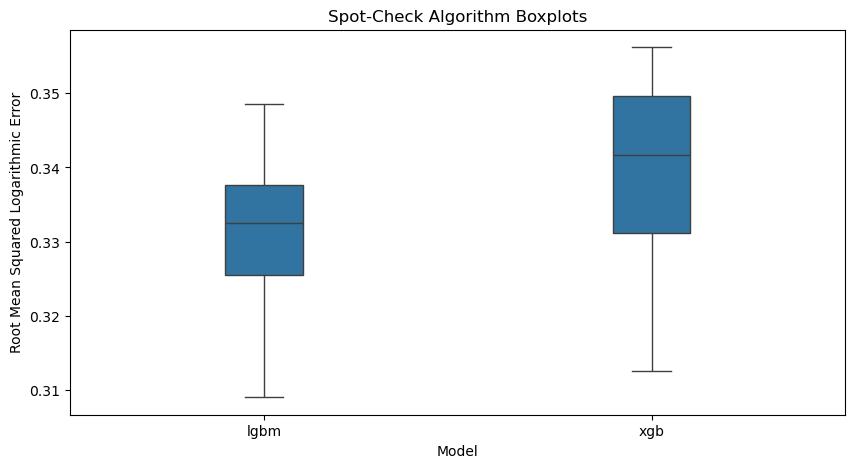

,lgbm,xgb
0,0.330295,0.356224
1,0.334904,0.340333
2,0.325430,0.330933
3,0.348625,0.342986
4,0.309003,0.312593
5,0.325631,0.331895
6,0.338473,0.353775
7,0.320333,0.350971
8,0.334764,0.322186
9,0.343974,0.345430


In [156]:
# Algorithm Comparison Boxplot
plt.figure(figsize=(10,5))
sns.boxplot(x='Model', y='Root Mean Squared Logarithmic Error',
            width=0.2,
            data=pd.melt(results, var_name='Model', value_name='Root Mean Squared Logarithmic Error'))
plt.title('Spot-Check Algorithm Boxplots')
plt.show()
display(results)

# Best Model on Entire Training Set
Choosing simpler model of LGBM over Stacking Regressor. Results are similar.

In [157]:
# Best Model
model = LGBMRegressor(n_estimators=50, verbosity=-1, silent=True)

# Pipeline
model_pipeline_steps = []
model_pipeline_steps.append(('preprocessing', preprocessing_transformer))
model_pipeline_steps.append(('model', model))
model_pipeline = Pipeline(steps=model_pipeline_steps)
final_model = TransformedTargetRegressor(regressor=model_pipeline, transformer=target_pipeline)
final_model.fit(X, y)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...rbosity=-1))])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",Pipeline(step...='box-cox'))])
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",None
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['season','holiday','workingday',...,'dt_year','dt_hour','dt_day']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying regressor exposes such an attribute when fit... versionadded:: 0.24,int,9
regressor_ regressor_: objectFitted regressor.,Pipeline,Pipeline(step...rbosity=-1))])
transformer_ transformer_: objectTransformer used in :meth:`fit` and :meth:`predict`.,Pipeline,Pipeline(step...='box-cox'))])
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"


## Predictions

In [158]:
# Predictions
predictions = final_model.predict(test)

# Submission
submission_model = 'LGBM'
submission = pd.DataFrame({'datetime':sample_submission['datetime'], 'count': predictions})
submission_file_name = 'submissions/' + submission_model + ' on ' + datetime.now().strftime("%Y %b %d at %H.%M.%S") + '.csv'
submission.to_csv(submission_file_name, index=False)
submission.head(5)

,datetime,count
0,2011-01-20 00:00:00,14.976484
1,2011-01-20 01:00:00,8.674126
2,2011-01-20 02:00:00,6.039768
3,2011-01-20 03:00:00,4.776917
4,2011-01-20 04:00:00,3.262396
